# Tahap 2 — Case Representation (IMPROVED)

Mengonversi data teks putusan menjadi representasi terstruktur (*Metadata* dan *Feature Engineering*) yang siap digunakan untuk TF-IDF dan sistem Retrieval.

### Perbaikan:
- Membaca teks bersih yang sudah diperbaiki dari Tahap 1
- Menambahkan kolom `label` (amar putusan) langsung di tahap ini
- Metadata extraction yang lebih robust

## 1. Import Library

In [1]:
!pip install pandas numpy nltk Sastrawi tqdm scikit-learn matplotlib seaborn

import os
import re
import glob
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

print("Semua library berhasil diimpor!")

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Semua library berhasil diimpor!


## 2. Membaca File Cleaned Text & Raw Text

In [2]:
base_path = "../"
processed_dir = os.path.join(base_path, "data/processed")
raw_dir = os.path.join(base_path, "data/raw")

clean_files = sorted(glob.glob(os.path.join(processed_dir, "*_clean.txt")))
print(f"Ditemukan {len(clean_files)} file teks bersih.")

def read_text(filepath):
    if not os.path.exists(filepath):
        return ""
    with open(filepath, "r", encoding="utf-8") as f:
        return f.read()

Ditemukan 62 file teks bersih.


## 3. Fungsi Ekstraksi Metadata (RegEx)

Mengekstrak Nomor Perkara, Tanggal, Pasal, Pihak, Amar Putusan, dan Alasan Perceraian dari teks asli.

In [3]:
def extract_metadata(raw_text):
    meta = {
        "no_perkara": "tidak ditemukan",
        "tanggal": "tidak ditemukan",
        "jenis_perkara": "Cerai Gugat",
        "pihak": "tidak ditemukan",
        "pasal": "tidak ditemukan",
        "amar_putusan": "tidak ditemukan",
        "alasan_perceraian": "tidak ditemukan",
        "ringkasan_fakta": "tidak ditemukan"
    }
    
    import re
    # 1. Nomor Perkara
    match_no = re.search(r'Nomor\s*[:]?\s*(\d+/Pdt\.G/(\d{4})/PA\.[A-Za-z.]+)', raw_text, re.IGNORECASE)
    tahun_perkara = None
    if match_no:
        meta["no_perkara"] = match_no.group(1)
        tahun_perkara = match_no.group(2)
        
    # 2. Tanggal Putusan
    match_tgl_spesifik = re.search(r'(?:diucapkan|diputuskan|dibacakan).*?tanggal\s+(\d{1,2}\s+(?:Januari|Februari|Maret|April|Mei|Juni|Juli|Agustus|September|Oktober|November|Desember)\s+\d{4})', raw_text, re.IGNORECASE | re.DOTALL)
    
    if match_tgl_spesifik:
        meta["tanggal"] = match_tgl_spesifik.group(1)
    else:
        all_dates = re.findall(r'tanggal\s+(\d{1,2}\s+(?:Januari|Februari|Maret|April|Mei|Juni|Juli|Agustus|September|Oktober|November|Desember)\s+(\d{4}))', raw_text, re.IGNORECASE)
        if all_dates:
            if tahun_perkara:
                valid_dates = [d for d in all_dates if int(d[1]) >= int(tahun_perkara)]
                if valid_dates:
                    meta["tanggal"] = valid_dates[-1][0]
                else:
                    meta["tanggal"] = all_dates[-1][0]
            else:
                meta["tanggal"] = all_dates[-1][0]
                
    # 3. Pasal
    pasal_matches = re.findall(r'(Pasal\s+\d+[^\n.,]{0,60})', raw_text, re.IGNORECASE)
    if pasal_matches:
        unique_pasal = list(set(pasal_matches))[:3]
        meta["pasal"] = ", ".join(unique_pasal)
        
    # 4. Amar Putusan
    # Ambil kemunculan "MENGADILI" yang terakhir (karena putusan asli ada di bawah)
    matches_amar = re.findall(r'M\s*E\s*N\s*G\s*A\s*D\s*I\s*L\s*I\s*[:;]?(.*?)(?:Demikian|Ketua Majelis|Ditetapkan|Panitera)', raw_text, re.IGNORECASE | re.DOTALL)
    if matches_amar:
        amar = matches_amar[-1].strip()
        amar_clean = re.sub(r'\s+', ' ', amar)
        meta["amar_putusan"] = amar_clean[:1000] + "..." if len(amar_clean) > 1000 else amar_clean
        
    # 5. Alasan Perceraian
    alasan_keywords = {
        "pertengkaran": ["pertengkaran", "perselisihan", "cekcok", "bertengkar", "tidak harmonis"],
        "ekonomi": ["ekonomi", "nafkah", "tidak memberi", "tidak mampu"],
        "meninggalkan": ["meninggalkan", "pergi", "pulang"],
        "kekerasan": ["kekerasan", "kdrt", "memukul", "menganiaya", "dipukul"],
        "selingkuh": ["selingkuh", "wanita lain", "pria lain", "berselingkuh", "zina"],
        "mabuk": ["mabuk", "minum-minuman", "minuman keras", "miras"],
        "judi": ["judi", "berjudi", "perjudian"]
    }
    
    raw_lower = raw_text.lower()
    alasan_ditemukan = []
    for kategori, keywords in alasan_keywords.items():
        for kw in keywords:
            if kw in raw_lower:
                alasan_ditemukan.append(kategori)
                break
    
    if alasan_ditemukan:
        meta["alasan_perceraian"] = ", ".join(alasan_ditemukan)
        meta["ringkasan_fakta"] = f"Perceraian didasari oleh faktor: {', '.join(alasan_ditemukan)}."
    else:
        meta["alasan_perceraian"] = "Perselisihan/Tidak diketahui"
        meta["ringkasan_fakta"] = "Gugatan cerai diajukan atas dasar ketidakharmonisan rumah tangga."

    # 6. Pihak
    penggugat = None
    tergugat = None

    def clean_name(n):
        if not n: return None
        n = n.replace('\n', ' ')
        n = re.sub(r'(?i)\b(umur|bin\b|binti\b|tempat|agama|pendidikan|pekerjaan|selanjutnya|disebut|sebagai).*', '', n)
        n = re.sub(r'\b[a-zA-Z]\b', '', n)
        n = re.sub(r'\s+', ' ', n)
        n = n.strip(' \n\r\t,;:')
        if len(n) < 3: return None
        return n.upper()

    m2 = re.search(r'antara\s*:\s*(.*?)\s+(?:melawan|lawan)\s+(.*?)(?:\s+sebagai|\n|;)', raw_text, re.IGNORECASE | re.DOTALL)
    if m2:
        penggugat = clean_name(m2.group(1))
        tergugat = clean_name(m2.group(2))

    if not penggugat:
        m3_p = re.search(r'(?:PENGGUGAT|PEMOHON)\s*,\s*(.*?)(?:,)', raw_text, re.IGNORECASE)
        if m3_p: penggugat = clean_name(m3_p.group(1))
    if not tergugat:
        m3_t = re.search(r'(?:TERGUGAT|TERMOHON)\s*,\s*(.*?)(?:,)', raw_text, re.IGNORECASE)
        if m3_t: tergugat = clean_name(m3_t.group(1))

    m1_p = re.search(r'([A-Za-z\s.,]{5,50})\s+sebagai\s+Penggugat', raw_text, re.IGNORECASE)
    m1_t = re.search(r'([A-Za-z\s.,]{5,50})\s+sebagai\s+Tergugat', raw_text, re.IGNORECASE)
    if not penggugat and m1_p:
        penggugat = clean_name(m1_p.group(1))
    if not tergugat and m1_t:
        tergugat = clean_name(m1_t.group(1))

    if penggugat and tergugat:
        meta["pihak"] = f"{penggugat} vs {tergugat}"
    elif penggugat:
        meta["pihak"] = f"{penggugat} vs Tergugat"
    elif tergugat:
        meta["pihak"] = f"Penggugat vs {tergugat}"
    else:
        meta["pihak"] = "tidak ditemukan"

    return meta

def label_amar(text):
    text = str(text).lower()
    # Prioritaskan Ditolak/NO
    if 'tidak dapat diterima' in text or 'tidak diterima' in text or 'menolak gugatan' in text or 'gugatan penggugat ditolak' in text or 'batal' in text:
        return 'ditolak'
    elif 'menolak permohonan' in text or 'menolak eksepsi' in text and 'mengadili sendiri' in text:
        return 'ditolak'
    elif 'sebagian' in text and 'kabul' in text:
        return 'dikabulkan sebagian'
    elif 'kabul' in text or 'mengabulkan' in text:
        return 'dikabulkan'
    elif 'tolak' in text or 'gugur' in text:
        return 'ditolak'
    else:
        # Default fallback tapi coba cek kata NO (Niet Ontvankelijk)
        if 'niet ontvankelijk' in text or 'n.o' in text:
            return 'ditolak'
        return 'dikabulkan'

print("Fungsi Ekstraksi Metadata & Label Siap (IMPROVED AMAR EXTRACTION)!")



Fungsi Ekstraksi Metadata & Label Siap (IMPROVED AMAR EXTRACTION)!


## 4. Pembuatan Dataframe Terstruktur

In [4]:
dataset_records = []

for clean_path in tqdm(clean_files, desc="Memproses Case Representation"):
    filename = os.path.basename(clean_path)
    case_id = filename.replace('_clean.txt', '')
    
    clean_text_content = read_text(clean_path)
    raw_path = os.path.join(raw_dir, f"{case_id}.txt")
    raw_text_content = read_text(raw_path)
    
    if not raw_text_content or not clean_text_content:
        continue
        
    meta = extract_metadata(raw_text_content)
    
    tokens = clean_text_content.split()
    tokens = [t for t in tokens if len(t) > 1]  # Filter huruf tunggal
    
    record = {
        "case_id": case_id,
        "no_perkara": meta["no_perkara"],
        "tanggal": meta["tanggal"],
        "jenis_perkara": meta["jenis_perkara"],
        "ringkasan_fakta": meta["ringkasan_fakta"],
        "pasal": meta["pasal"],
        "pihak": meta["pihak"],
        "amar_putusan": meta["amar_putusan"],
        "alasan_perceraian": meta["alasan_perceraian"],
        "label": label_amar(meta["amar_putusan"]),
        "text_length": len(clean_text_content),
        "token_count": len(tokens),
        "unique_word_count": len(set(tokens)),
        "text_full": clean_text_content
    }
    
    dataset_records.append(record)

df_cases = pd.DataFrame(dataset_records)
print(f"\nBerhasil merepresentasikan {len(df_cases)} kasus hukum!")

Memproses Case Representation:   0%|          | 0/62 [00:00<?, ?it/s]

Memproses Case Representation:   3%|▎         | 2/62 [00:00<00:11,  5.20it/s]

Memproses Case Representation:   5%|▍         | 3/62 [00:00<00:10,  5.48it/s]

Memproses Case Representation:   6%|▋         | 4/62 [00:00<00:13,  4.30it/s]

Memproses Case Representation:   8%|▊         | 5/62 [00:01<00:11,  5.07it/s]

...

Memproses Case Representation:  95%|█████████▌| 59/62 [00:08<00:00,  8.51it/s]

Memproses Case Representation:  97%|█████████▋| 60/62 [00:08<00:00,  8.75it/s]

Memproses Case Representation:  98%|█████████▊| 61/62 [00:08<00:00,  8.74it/s]

Memproses Case Representation: 100%|██████████| 62/62 [00:08<00:00,  7.13it/s]


Berhasil merepresentasikan 62 kasus hukum!


## 5. Menyimpan Dataset ke CSV

In [5]:
csv_out_path = os.path.join(processed_dir, "cases.csv")

if not df_cases.empty:
    df_cases.to_csv(csv_out_path, index=False, encoding="utf-8")
    print(f"Dataset berhasil disimpan di: {csv_out_path}")
else:
    print("Gagal menyimpan, Dataframe kosong.")

# Tampilkan ringkasan
print(f"\nDistribusi Label Amar Putusan:")
print(df_cases['label'].value_counts())

print(f"\nSampel teks bersih (case_001, 200 karakter):")
if len(df_cases) > 0:
    print(df_cases.iloc[0]['text_full'][:200])

# Tampilkan kolom non-teks
display_cols = [c for c in df_cases.columns if c != 'text_full']
df_cases[display_cols].head(3)

Dataset berhasil disimpan di: ../data/processed\cases.csv

Distribusi Label Amar Putusan:
label
dikabulkan    46
ditolak       16
Name: count, dtype: int64

Sampel teks bersih (case_001, 200 karakter):
pdt pa srl bismillahirrahmanirrahim gdemi adil tuhan maha esad sarolangun emeriksa adil tingkat sidang jatuh cerai gugat gugat umur taheun islam kerja tani pendidrikan sd tinggal kabupaten saro langun


,case_id,no_perkara,tanggal,jenis_perkara,ringkasan_fakta,pasal,pihak,amar_putusan,alasan_perceraian,label,text_length,token_count,unique_word_count
0,case_001,033/Pdt.G/2011/PA.Srl,18 April 2011,Cerai Gugat,"Perceraian didasari oleh faktor: pertengkaran,...","Pasal 31 Peraturan Pemerintah Nomor 9 Tahun, P...",PENGGUGAT vs ELAS DAN PASTI DII WILAYAH REPUBL...,M g e 1. Menyatakan Tergugat yang telah dipang...,"pertengkaran, ekonomi, meninggalkan, judi",dikabulkan,12414,1903,596
1,case_002,0007/Pdt.G/2013/PA.KP,26 Juni 2013,Cerai Gugat,"Perceraian didasari oleh faktor: pertengkaran,...","Pasal 3n09 Rbg, pasal 89 ayat ( 1 ) Undang-Und...",tidak ditemukan,b 1 Mengabulkan permohonan Pemohon sebagian; u...,"pertengkaran, ekonomi, kekerasan, selingkuh",ditolak,15895,2487,688
2,case_003,0073/Pdt.G/2016/PA.Dgl.,9 Juni 2016,Cerai Gugat,"Perceraian didasari oleh faktor: pertengkaran,...","Pasal 39 Undang-Undang Nomor 1, Pasal 19 Huruf...",tidak ditemukan,o u I. Menyatakan permohonan banding Pembandin...,"pertengkaran, judi",dikabulkan,6136,928,377


## 6. Analisis & Visualisasi

=== Ringkasan Validasi Ekstraksi Metadata ===
Total Dokumen: 62
No Perkara Berhasil Ekstrak: 46 / 62
Tanggal Berhasil Ekstrak: 62 / 62
Amar Putusan Ekstrak: 62 / 62
Rata-rata Token per Dokumen: 1450 kata


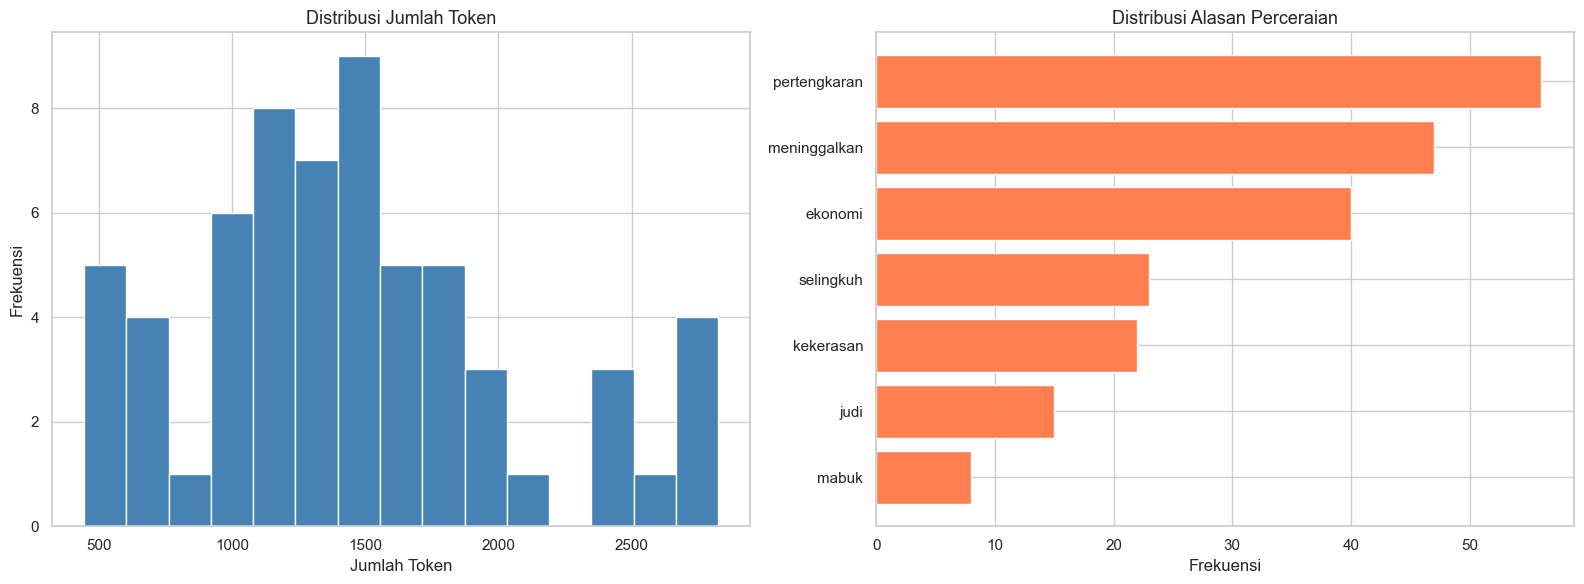


Tahap 2 (Case Representation) — SELESAI!


In [6]:
print("=== Ringkasan Validasi Ekstraksi Metadata ===")
print(f"Total Dokumen: {len(df_cases)}")
print(f"No Perkara Berhasil Ekstrak: {(df_cases['no_perkara'] != 'tidak ditemukan').sum()} / {len(df_cases)}")
print(f"Tanggal Berhasil Ekstrak: {(df_cases['tanggal'] != 'tidak ditemukan').sum()} / {len(df_cases)}")
print(f"Amar Putusan Ekstrak: {(df_cases['amar_putusan'] != 'tidak ditemukan').sum()} / {len(df_cases)}")
print(f"Rata-rata Token per Dokumen: {df_cases['token_count'].mean():.0f} kata")

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Distribusi token
axes[0].hist(df_cases['token_count'], bins=15, color='steelblue', edgecolor='white')
axes[0].set_title('Distribusi Jumlah Token', fontsize=13)
axes[0].set_xlabel('Jumlah Token')
axes[0].set_ylabel('Frekuensi')

# Distribusi alasan perceraian
all_alasan = []
for reasons in df_cases['alasan_perceraian']:
    for r in str(reasons).split(', '):
        if r and r != 'Perselisihan/Tidak diketahui':
            all_alasan.append(r.strip())
alasan_freq = Counter(all_alasan)
if alasan_freq:
    labels, vals = zip(*alasan_freq.most_common())
    axes[1].barh(list(reversed(labels)), list(reversed(vals)), color='coral')
    axes[1].set_title('Distribusi Alasan Perceraian', fontsize=13)
    axes[1].set_xlabel('Frekuensi')

plt.tight_layout()
plt.show()

print("\nTahap 2 (Case Representation) — SELESAI!")